## Import library and samples

In [1]:
#import libraries and define figures repo
import scanpy as sc
import os
import numpy as np
sc.settings.figdir = "figures/"


In [2]:
os.getcwd()
os.chdir("/Users/annacarolinafagundes/ibd-myeloid-scoring/") #change wd


In [3]:
#list files of directory
data_dir = "data/raw/scrna"
for filename in os.listdir(data_dir):
    print(filename)

GSM6614364_CD-5
GSM6614349_HC-2
GSM6614360_CD-1
.DS_Store
GSM6614352_HC-5
GSM6614362_CD-3
GSM6614358_UC-5
GSM6614363_CD-4
GSM6614355_UC-2
GSM6614353_HC-6
GSM6614356_UC-3
GSE214695_cell_annotation.csv
GSM6614357_UC-4
GSM6614361_CD-2
GSM6614348_HC-1
GSM6614365_CD-6
GSM6614354_UC-1
GSM6614351_HC-4
GSM6614359_UC-6
GSM6614350_HC-3


### Extract sample names and create new folder for each sample

In [ ]:
#create new folder for each sample and skip annotation file
for filename in os.listdir(data_dir):
    
    # skip non-sample files
    if not filename.endswith(".gz"):
        continue
    
    # extract sample name and file type
    parts = filename.split("_")
    sample_name = parts[0] + "_" + parts[1]
    file_type = parts[2]

    print(sample_name, file_type)
    
     # create sample folder if it doesn't exist
    sample_dir = os.path.join(data_dir, sample_name)
    os.makedirs(sample_dir, exist_ok=True)
    
    # move and rename the file
    old_path = os.path.join(data_dir, filename)
    new_path = os.path.join(sample_dir, file_type)
    os.rename(old_path, new_path)

In [ ]:
#read matrices
adata = sc.read_10x_mtx(
    "data/raw/scrna/GSM6614348_HC-1",
    var_names="gene_symbols",
    cache=True
)
print(adata)

In [ ]:
#anndata structure
print(adata.obs) #cells (barcode symbols)
print(adata.var) #gene names
print(adata.X) #count matrix

In [ ]:
#create anndata object for each folder and filter empty droplets (for memory saving purposes)
adatas = []
for sample in os.listdir(data_dir):
    if not sample.startswith("GSM"):
        continue
    print(f"Loading {sample}...")
    adata = sc.read_10x_mtx(
        os.path.join(data_dir, sample),
        var_names="gene_symbols",
        cache=True #First time: scanpy reads the .gz files, decompresses them, then saves a processed copy as an .h5ad file in the same folder
    )
    #here I would run scrublet normally, but due to processing constraints had to skip
    # filter empty barcodes immediately
    counts_per_barcode = np.asarray(adata.X.sum(axis=1)).flatten()
    adata = adata[counts_per_barcode > 500] #total read counts per droplet
    # add sample column to metadata
    adata.obs["sample"] = sample  
    # add condition column to metadata
    condition = sample.split("_")[1].split("-")[0] #first split ["GSM6614348", "HC-1"] and takes "HC-1" then split it and takes "HC"
    adata.obs["condition"] = condition 
    print(f"  Kept {adata.n_obs} cells")
    #append list
    adatas.append(adata)


Loading GSM6614364_CD-5...


/Users/annacarolinafagundes/anaconda3/envs/ibd-myeloid/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
/var/folders/5x/6cxhjcxs5p79bg6pfvths8tr0000gn/T/ipykernel_89217/826074857.py:18: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["sample"] = sample


  Kept 2038 cells
Loading GSM6614349_HC-2...


/Users/annacarolinafagundes/anaconda3/envs/ibd-myeloid/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
/var/folders/5x/6cxhjcxs5p79bg6pfvths8tr0000gn/T/ipykernel_89217/826074857.py:18: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["sample"] = sample


  Kept 4309 cells
Loading GSM6614360_CD-1...


/Users/annacarolinafagundes/anaconda3/envs/ibd-myeloid/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
/var/folders/5x/6cxhjcxs5p79bg6pfvths8tr0000gn/T/ipykernel_89217/826074857.py:18: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["sample"] = sample


  Kept 3526 cells
Loading GSM6614352_HC-5...


/Users/annacarolinafagundes/anaconda3/envs/ibd-myeloid/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


ValueError: n_components=21 must be strictly less than min(n_samples, n_features)=21 with svd_solver='arpack'

In [ ]:
#Inspect if the dimensions look fine
for i, adata in enumerate(adatas):
    print(i, adata.n_obs)

### Filtering and QC

In [ ]:
#check if samples are unique 
for adata in adatas:
    print(adata.obs["sample"].unique())


In [ ]:
#merge samples into one object and perform sanity check
adata_combined = sc.concat(adatas)
print(adata_combined)
adata_combined.obs["condition"].value_counts()


In [ ]:
#save unfiltered, processed object
adata_combined.write("data/processed/adata_combined_raw.h5ad")


In [6]:
#load
os.chdir("/Users/annacarolinafagundes/ibd-myeloid-scoring/") #change wd
adata_combined = sc.read_h5ad("data/processed/scrna/adata_combined_raw.h5ad")
print(adata_combined)

AnnData object with n_obs × n_vars = 75489 × 33538
    obs: 'sample', 'condition'


/Users/annacarolinafagundes/anaconda3/envs/ibd-myeloid/lib/python3.11/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [7]:
# if needed delete unnecessary objects (memory management)
del adatas          # delete the list — no longer needed
del counts_per_barcode
del adata

In [8]:
#detect mitochondrial, ribosimal and hemoglobin genes
adata_combined.var["mt"] = adata_combined.var_names.str.startswith("MT-")
adata_combined.var["ribo"] = adata_combined.var_names.str.startswith(("RPS", "RPL"))
adata_combined.var["hb"] = adata_combined.var_names.str.contains("^HB[^(P)]")

In [9]:
#inspect number of genes
print("MT genes:", adata_combined.var["mt"].sum())
print("Ribo genes:", adata_combined.var["ribo"].sum())
print("HB genes:", adata_combined.var["hb"].sum())

MT genes: 13
Ribo genes: 104
HB genes: 12


In [10]:
#calculate QC metrics
sc.pp.calculate_qc_metrics(
    adata_combined,
    qc_vars=["mt", "ribo", "hb"], #flag genes in var, stores results as pct in obs
    inplace=True, #replace the object instead of creating a new one
    log1p=True)


In [ ]:
#export to visualize data structure
adata_combined.obs.to_csv("obs_check.csv") #object metatada/ rows:barcode / cols: metadata cols
adata_combined.var.to_csv("var_check.csv") #gene metadata/ rows: gene / cols: mean counts


In [ ]:
#visualize QC metrics general
sc.pl.violin(
    adata_combined,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    save="_qc_violin.png" #because we already set the figures repo in the beginning
)
#visualize QC metrics per sample

sc.pl.violin(
    adata_combined,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    groupby="sample",
    save="_qc_violin_per_sample.png"
)



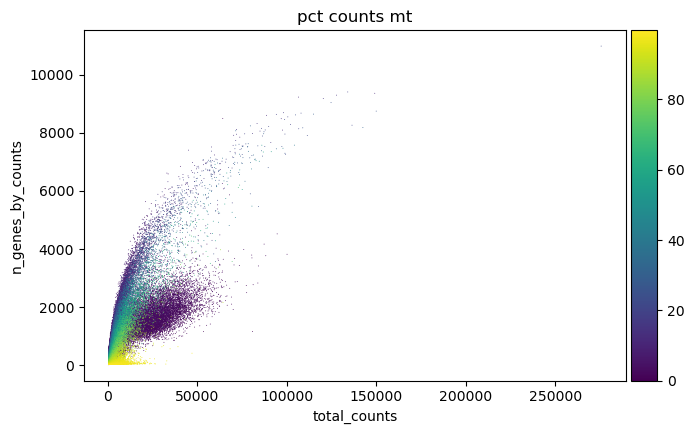

In [11]:
#visualize QC metrics 
sc.pl.scatter(adata_combined, "total_counts", 
              "n_genes_by_counts", 
              color="pct_counts_mt",
              save="_qc_scatter.png")

In [ ]:
#permissive filtering first
sc.pp.filter_cells(adata_combined, min_genes=100)
sc.pp.filter_genes(adata_combined, min_cells=3)

In [12]:
os.getcwd()

'/Users/annacarolinafagundes/ibd-myeloid-scoring'